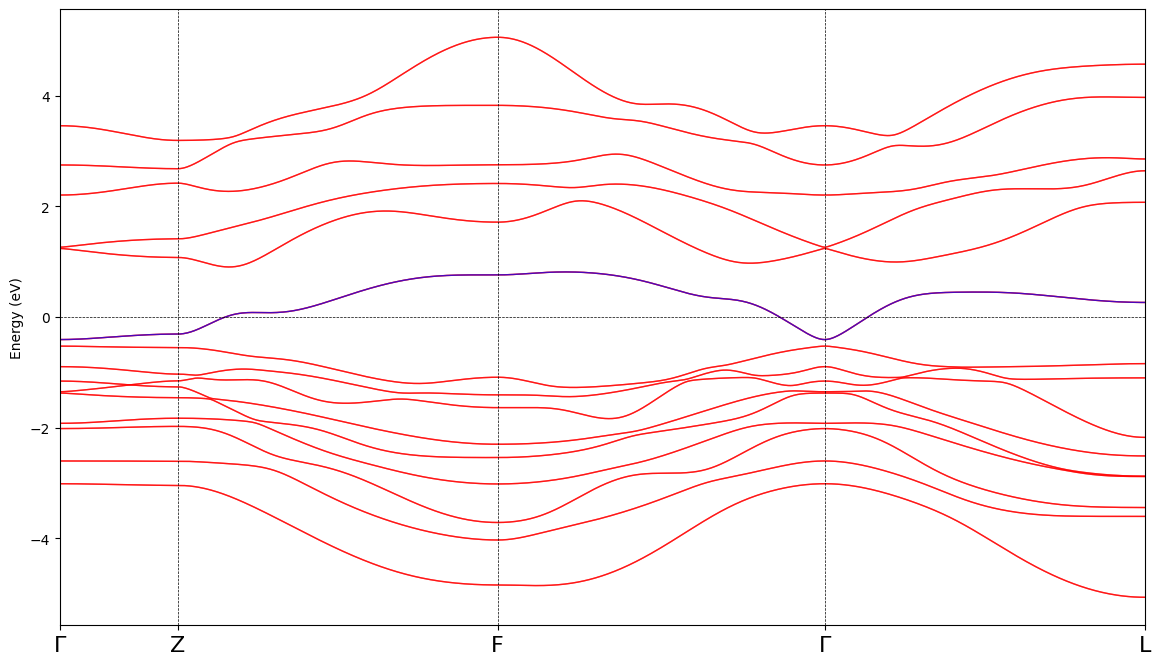

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np


data = np.loadtxt('wannier_band.dat')

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

fermi_level = 7.8524

high_symmetry_points = [0, 0.3207858016, 1.1898687664, 2.0784667187, 2.9475498198]  
high_symmetry_labels = [r'$\Gamma$','Z', 'F', r'$\Gamma$','L']

plt.figure(figsize=(14, 8))

for band in range(len(bands)):
    plt.plot(k, bands[band, :]-fermi_level, linewidth=1, alpha=0.7, color='red')
plt.xlim(min(k), max(k))

plt.plot(k, bands[19, :]-fermi_level, linewidth=1, alpha=0.7, color='blue')

plt.axhline(0, color='black', linestyle='--', lw=0.5)
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel("Energy (eV)")
#plt.ylim(-5,5)
plt.show()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2025-11-16 14:36:22,272                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(8, 27, 2)                                  |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

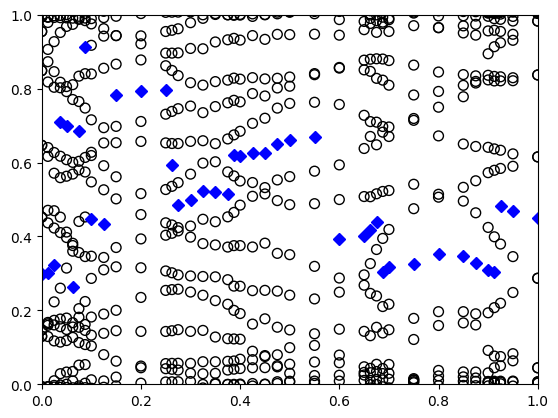

In [11]:
import z2pack
import tbmodels
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='wannier_hr.dat',occ=14)
system = z2pack.tb.System(model)
result = z2pack.surface.run(
    system=system,
    surface=lambda t1, t2: [t1/2,t2,0.5],
)
   # Prints the Chern number

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()      # Prints the Z2 invariant